# Netflix Titles — Quick EDA

Dataset: `data_lake/raw/netflix_titles.csv`

Columns: show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description

In [ ]:
# %pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

In [12]:
path = "../data_lake/raw/netflix_titles.csv"
df = pd.read_csv(path)

display(df.head())
df.shape

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


(8807, 12)

In [4]:
df.info()

missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


director      0.299080
country       0.094357
cast          0.093675
date_added    0.001135
rating        0.000454
duration      0.000341
dtype: float64

In [5]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

df[["date_added", "year_added"]].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [13]:
# show duplicates in show_id
dupes = df[df["show_id"].duplicated(keep=False)].sort_values("show_id")
dupes

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


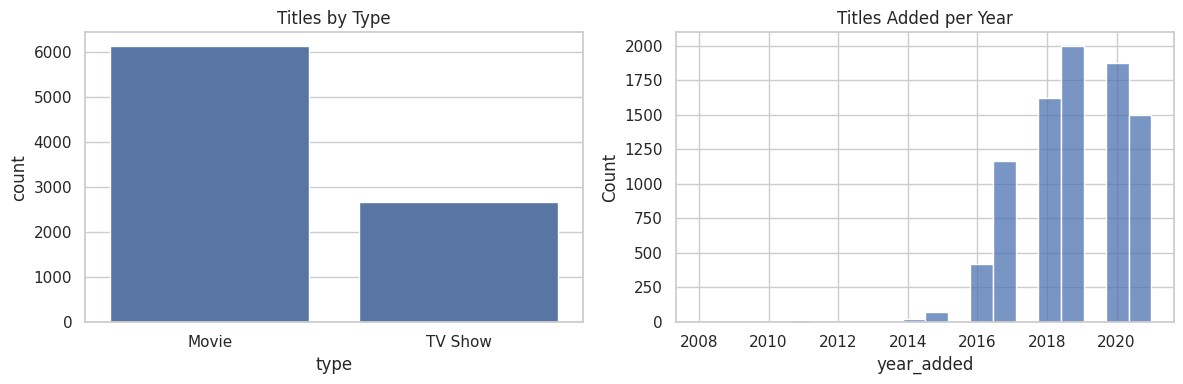

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="type", data=df, ax=ax[0])
sns.histplot(df["year_added"].dropna(), bins=20, ax=ax[1])

ax[0].set_title("Titles by Type")
ax[1].set_title("Titles Added per Year")
plt.tight_layout()

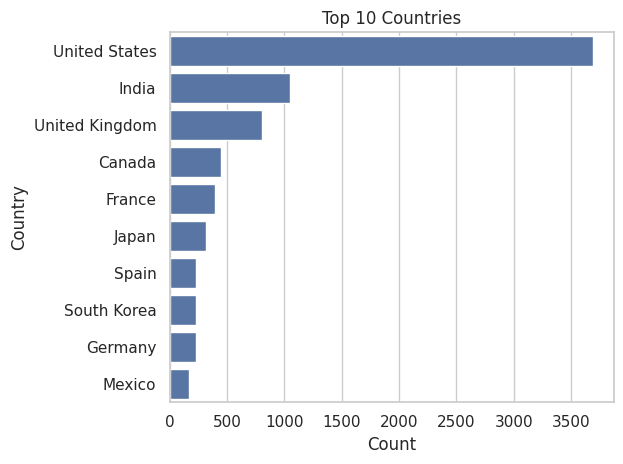

In [7]:
country_counts = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

country_counts

sns.barplot(y=country_counts.index, x=country_counts.values)
plt.title("Top 10 Countries")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()

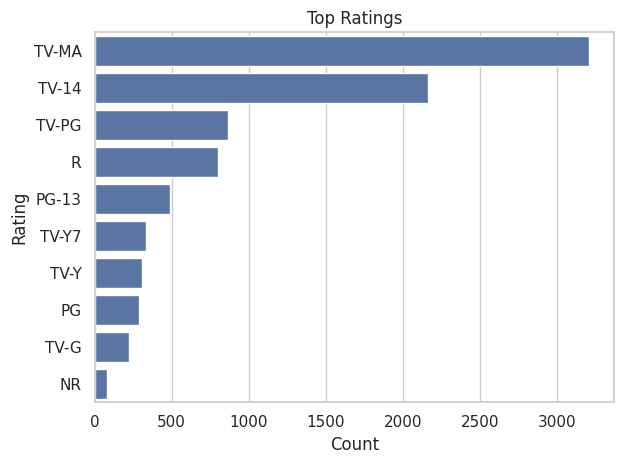

In [8]:
rating_counts = df["rating"].value_counts().head(10)

sns.barplot(y=rating_counts.index, x=rating_counts.values)
plt.title("Top Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.tight_layout()

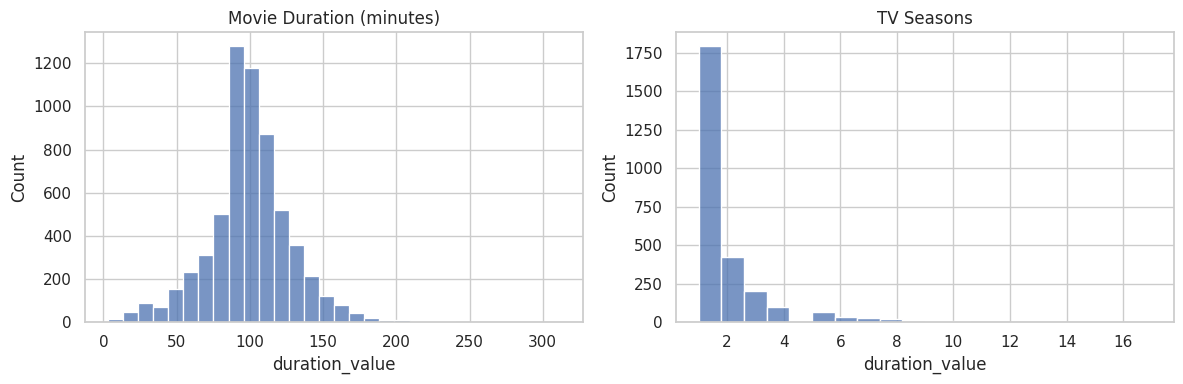

In [14]:
def parse_duration(s):
    if pd.isna(s):
        return np.nan, np.nan
    parts = s.split(" ")
    if len(parts) < 2:
        return np.nan, np.nan
    value = pd.to_numeric(parts[0], errors="coerce")
    unit = parts[1].lower()
    if unit.startswith("season"):
        unit = "season"
    elif unit.startswith("min"):
        unit = "min"
    return value, unit

duration = df["duration"].apply(parse_duration)
df["duration_value"] = duration.apply(lambda x: x[0])
df["duration_unit"] = duration.apply(lambda x: x[1])

movies = df[df["duration_unit"] == "min"]
tv = df[df["duration_unit"] == "season"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(movies["duration_value"].dropna(), bins=30, ax=ax[0])
sns.histplot(tv["duration_value"].dropna(), bins=20, ax=ax[1])

ax[0].set_title("Movie Duration (minutes)")
ax[1].set_title("TV Seasons")
plt.tight_layout()

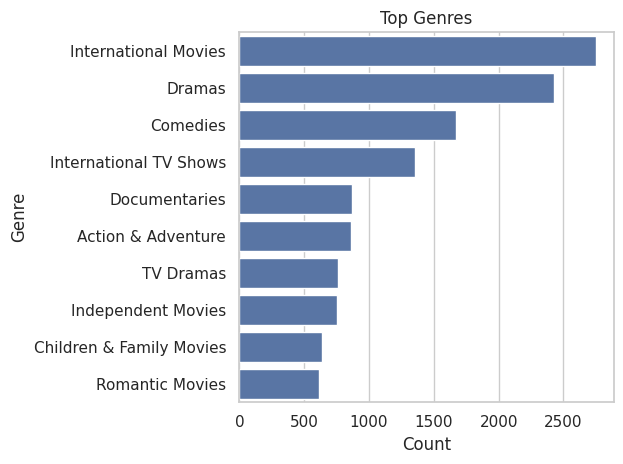

In [10]:
genres = df["listed_in"].dropna().str.split(", " ).explode()
genre_counts = genres.value_counts().head(10)

sns.barplot(y=genre_counts.index, x=genre_counts.values)
plt.title("Top Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()

## Notes / Next Steps
- Explore director/cast networks.
- Build time-series by release_year vs. date_added.
- Clean countries and genres into dimension tables.

# Cleaning

In [15]:
for col in ['director','cast','country']:
    df[col] = df[col].fillna('Unknown')

In [16]:
stage_path = '../data_lake/staging/netflix_titles_staging.csv'
df.to_csv(stage_path, index=False)
print('Saved to STAGING')

Saved to STAGING
